##### 2. to project monthly EOF onto daily GH anomalies (reattempt)

In [1]:
import numpy as np
import xarray as xr

In [2]:
import glob

In [3]:
from pathlib import Path

cwd = Path.cwd()
era5_dir = cwd.parents[6]

# build a path relative to two-up:
gh_dir = era5_dir / 'shared_data/Datasets/ERA5/plev'

In [4]:
ilev = 1000 # Pa

def pre(ds): return ds[['var129']].sel(lat=slice(-20,-90)).sel(plev=ilev)

In [5]:
mons = np.arange(7,12+1,1)

In [6]:
mon = 6

In [16]:
gh_day_mon = gh_6h_mon['var129'].resample(time="1D").mean()

In [17]:
gh_day_mon.groupby("time.dayofyear").mean("time")

<xarray.DataArray 'var129' (dayofyear: 366, lat: 36, lon: 180)> Size: 9MB
dask.array<transpose, shape=(366, 36, 180), dtype=float32, chunksize=(27, 36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon        (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev       float64 8B 1e+03
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Attributes:
    table:    128

In [18]:
# convert z (m^2/s^2) -> meters and apply weights AFTER the averaging
w = np.sqrt(np.cos(np.deg2rad(gh_day_mon['lat'])))  # √cos(lat), 1D
pwt_mon = (gh_day_mon / 9.8)* w                  # weighted monthly fields


In [19]:
pwt_mon

<xarray.DataArray (time: 16436, lat: 36, lon: 180)> Size: 852MB
dask.array<mul, shape=(16436, 36, 180), dtype=float64, chunksize=(27, 36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
  * time     (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31

In [21]:
gh_daily_clim

NameError: name 'gh_daily_clim' is not defined

In [14]:
# for mon in mons:
# print(mon)
gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*.nc")

gh_6h_mon = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
gh_6h_mon = gh_6h_mon.sel(time=slice('1979-01-01', '2023-12-31'))  # years 1979–2023

gh_day_mon = gh_6h_mon['var129'].resample(time="1D").mean()

# Convert to meters
z_m = gh_day_mon / 9.8

# Compute climatology in meters
z_clim = z_m.groupby("time.dayofyear").mean("time")

# Compute anomalies (unweighted)
z_anom = z_m.groupby("time.dayofyear") - z_clim

# THEN apply weights
w = np.cos(np.deg2rad(z_anom['lat']))


/usr/local/Miniconda3-envs/envs/2024/envs/iacpy3_2024/lib/python3.11/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 45 times more chunks
  return self.array[key]


In [15]:
pwt_anom = z_anom * w

- open monthly eof

In [ ]:
mon = 6

In [ ]:
feof = f'processed/zeof/ERA5.EOF1.z10.Mon{mon:02d}.nc'

In [ ]:
xeof1 = xr.open_dataset(feof)

In [ ]:
eof1 = xeof1['eof1']

In [ ]:
eof1 

In [ ]:
anom_mon = pwt_anom.where(gh_day_mon['time'].dt.month==mon, drop=True)

In [ ]:
feof = f'processed/zeof/ERA5.EOF1.z10.Mon06.nc'

xeof1 = xr.open_dataset(feof)
eof1 = xeof1['eof1']

In [ ]:
mon = 6

In [ ]:
mu = pc1_daily.groupby('time.dayofyear').mean('time')

In [ ]:
std = pc1_daily.groupby('time.dayofyear').std('time')

In [ ]:
mu

In [ ]:
pc1_daily.values

In [ ]:
std.values

In [ ]:
mu.values

In [ ]:
(18795.932-105)/14295.77

In [ ]:
pc1_daily_std.values

In [ ]:
pwt_anom

In [ ]:
eof1

In [ ]:
import numpy as np
import xarray as xr

R = 6_371_000.0  # Earth radius (m)

pc1_daily_mons = []

for mon in range(6, 13):
    print(mon)
    feof = f'processed/zeof/ERA5.EOF1.z10.Mon{mon:02d}.nc'
    eof1 = xr.open_dataset(feof)['eof1']

    # Select daily anomalies for this month (UNWEIGHTED anomalies here)
    # If you currently have pwt_anom = z_anom * sqrt(cos(lat)),
    # then undo the weight to get unweighted anomalies:
    # z_anom = pwt_anom / np.sqrt(np.cos(np.deg2rad(pwt_anom.lat)))
    z_anom_mon = z_anom.where(z_anom['time'].dt.month == mon, drop=True)

    # Align EOF to anomalies
    eof1 = eof1.sel(lat=z_anom_mon.lat, lon=z_anom_mon.lon)

    # --- cell area (m^2) for this grid ---
    # assume regular spacing; compute scalar spacings in degrees
    dlat_deg = float(np.abs(np.gradient(z_anom_mon.lat.values)).mean())
    dlon_deg = float(np.abs(np.gradient(z_anom_mon.lon.values)).mean())
    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)
    phi  = np.deg2rad(z_anom_mon.lat)

    band = np.sin(phi + dlat/2) - np.sin(phi - dlat/2)  # per-lat strip
    cell_area = (R**2) * dlon * band                   # (lat,) -> broadcast
    cell_area = cell_area.broadcast_like(z_anom_mon)

    # Normalize EOF with the same inner product: sum(EOF^2 * area) = 1
    norm = np.sqrt(((eof1**2) * cell_area.isel(time=0, drop=True)).sum(['lat','lon']))
    eof1_aw = eof1 #/ norm

    # Projection with area-weighted inner product (resolution-invariant)
    pc1_daily = ((z_anom_mon * eof1_aw) * cell_area).sum(['lat', 'lon'])

    # ---- STANDARDIZE across years for each day-of-month (NCL dims=0) ----
    g   = pc1_daily.groupby('time.day')
    mu  = g.mean('time')
    std = g.std('time', ddof=1)
    pc1_daily_std = (g - mu).groupby('time.day') / std

    pc1_daily_mons.append(pc1_daily_std)

pc1_daily_std_all = xr.concat(pc1_daily_mons, dim='time').sortby('time')


In [486]:
write_pc1_monthly_ascii(pc1_daily_std_all, lv=10, out_dir="./processed")


--- Writing Month 06 ---
✅ Wrote 45 files for month 06

--- Writing Month 07 ---
✅ Wrote 45 files for month 07

--- Writing Month 08 ---
✅ Wrote 45 files for month 08

--- Writing Month 09 ---
✅ Wrote 45 files for month 09

--- Writing Month 10 ---
✅ Wrote 45 files for month 10

--- Writing Month 11 ---
✅ Wrote 45 files for month 11

--- Writing Month 12 ---
✅ Wrote 45 files for month 12


In [493]:
len(years)

45

In [553]:
originaleof = 'data/zeof/ERA5.EOF1.z10.Mon06.nc'

In [554]:
oeof = xr.open_dataset(originaleof)

In [555]:
reduce_oeof = oeof['eof1'].isel(
    lat=slice(0, None, 2),
    lon=slice(0, None, 2),
)

In [ ]:
pc1_daily = ((anom * eof1) * w).sum(dim=['lat','lon'])

In [733]:
mon = 6

pc1_daily_mon = np.ones([len(years), 30])

print(mon)
feof = f'processed/zeof_covariance/ERA5.EOF1.z10.Mon{mon:02d}.nc'

xeof1 = xr.open_dataset(feof)
eof1 = xeof1['eof1']

anom_mon = z_anom.where(gh_day_mon['time'].dt.month==mon, drop=True)
for i in range(len(years)):
    yr = years[i]
    anom_mon_yr = anom_mon.where(anom_mon['time'].dt.year == yr, drop=True)

    # w = np.sqrt(np.cos(np.deg2rad(anom_mon_yr.lat)))  # NOT sqrt; use cos(lat) here
    
    # pc1_daily = ((anom_mon_yr * eof1)*w).sum(dim=['lat', 'lon'])
    # pc1_daily_mon[i] = -pc1_daily


#####
    
    # anomalies UNweighted
    w = np.cos(np.deg2rad(z_anom.lat))
    W = w.broadcast_like(eof1)
    
    # (optional but recommended) normalize EOF in the same metric:
    eof1_n = eof1 #/ np.sqrt(((eof1**2) * W).sum(['lat','lon']))

    # projection uses the SAME metric (cos(lat)), not sqrt:
    pc1 = ((anom_mon_yr * eof1_n) * W).sum(['lat','lon'])
    pc1_daily_mon[i] = pc1

6


In [738]:
test_std = (pc1_daily_mon - np.nanmean(pc1_daily_mon, axis=0))/ np.nanstd(pc1_daily_mon, ddof=1, axis=0)

In [739]:
1979+5

1984

In [740]:
test_std[5]

array([ 2.1683692 ,  1.19548792,  0.59511909,  0.57438907,  0.95627626,
        1.4863371 ,  1.91078551,  2.09063505,  2.07712615,  1.81288967,
        1.43244078,  1.14983952,  1.04296793,  0.83923773,  0.47503184,
       -0.01959806, -0.29389427, -0.25874402, -0.23854823, -0.40280136,
       -0.60531973, -0.68765907, -0.70544295, -0.84641993, -1.05919315,
       -0.9524116 , -0.72314768, -0.79698175, -1.07919136, -1.19076877])

In [726]:
test_std[5]

array([-2.16359934, -1.11616496, -0.57574673, -0.72782229, -1.21796879,
       -1.72015309, -2.06323632, -2.18229492, -2.11669429, -1.80601577,
       -1.45760433, -1.24526541, -1.13678459, -0.85131734, -0.43229531,
        0.09813989,  0.3911351 ,  0.33968478,  0.3135427 ,  0.50049722,
        0.70015853,  0.74586246,  0.70526471,  0.76715652,  0.84194158,
        0.58806147,  0.37653982,  0.61933509,  1.00450876,  1.13803549])

In [687]:
test_std[6]/ncl

array([ 0.60943313,  0.64085387,  0.6327203 ,  0.52630342,  0.3951373 ,
        0.08343056, -4.59576655,  1.94000958,  1.45368589,  1.02541177,
        0.85722402,  0.7435429 ,  0.52296503,  0.39639813,  0.43789097,
        0.45878301,  0.49528429,  0.55533812,  0.60583707,  0.61721955,
        0.59477964,  0.57138029,  0.5821062 ,  0.63776578,  0.68771604,
        0.69235563,  0.6720132 ,  0.64607287,  0.58981624,  0.53366173])

Text(0.5, 1.0, '198506')

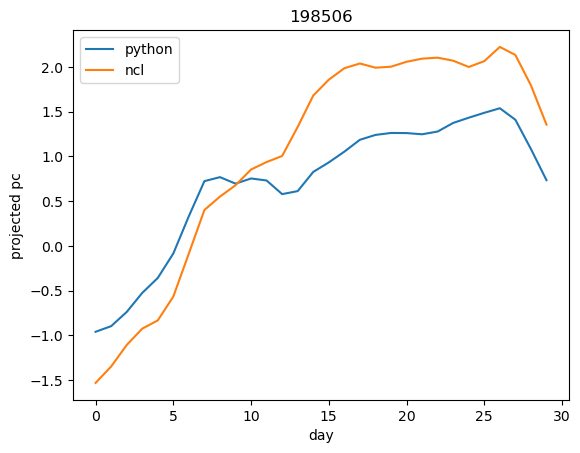

In [747]:
plt.plot(-test_std[6], label='python')
plt.plot(ncl, label='ncl')
plt.legend()

plt.ylabel('projected pc')
plt.xlabel('day')

plt.title('198506')

In [696]:
np.corrcoef(test_std[5], ncl)[0,1]

0.1419940426389332

In [721]:
x = test_std[5]
y = ncl

In [722]:
# x = your monthly vector (e.g., June 1979; standardized or raw)
# y = NCL monthly vector (same year/month/day indices)
A = np.vstack([x, np.ones_like(x)]).T
b, a = np.linalg.lstsq(A, y, rcond=None)[0]   # y ≈ a + b*x
corr = np.corrcoef(x, y)[0,1]
print("corr=", corr, "slope b=", b, "intercept a=", a)

corr= 0.14022100270764556 slope b= 0.041226653636000476 intercept a= 1.1231885030156508


In [746]:
s = """-1.530   -1.347   -1.107   -0.924   -0.832   -0.565   -0.084    0.402    0.551    0.678    0.854    0.937    1.005    1.330    1.680    1.857    1.985    2.038    1.991    2.002    2.057    2.092    2.103    2.069    1.999    2.064    2.223    2.133    1.794    1.355

"""
ncl = np.fromstring(s, sep=' ')

In [592]:
ncl

array([-0.601, -0.327,  0.195,  0.931,  1.39 ,  1.406,  1.274,  1.159,
        0.89 ,  0.253, -0.224, -0.3  , -0.252, -0.26 , -0.331, -0.561,
       -0.984, -1.364, -1.717, -2.013, -2.107, -2.05 , -2.004, -1.868,
       -1.616, -1.105, -0.872, -1.071, -1.167, -1.13 ])

In [528]:
np.nanmean(pc1_daily_mon, axis=0)

array([-111.22258432, -116.11330212,  -17.96955866,  114.11865391,
        163.79366074,   56.53770637,  -31.03333456,  -62.77418706,
        -71.07153655,  -62.54950797,   -0.9279267 ,   33.16734527,
         31.80854115,    8.63975037,  -97.88429861, -171.07966307,
        -39.38617047,   90.09927943,   36.91551091,  -13.30509219,
         57.00523449,   90.10445974,   48.93283459,   -5.1499348 ,
         48.25606661,   91.82589236,   54.54140981,  -15.9029051 ,
         -7.5000128 ,   79.4398336 ])

In [529]:
test_std.shape

(45, 30)

In [540]:
pc1_daily_mon[0]

array([ -956.34518834,  -581.44842844,  -923.62185926, -1341.90448506,
        -668.14820606,   717.0137211 ,   817.1835235 ,  -338.99828322,
       -1262.9393726 ,  -987.77739491,  -609.27039946, -1253.16302257,
       -1445.4343451 , -1047.16869412,  -518.90904889,    24.36927015,
         143.54256255,  -749.99859134,  -337.20486653,  1013.26307788,
        2194.19288318,  2080.99656786,   490.26254424,  -994.02424457,
       -1324.39264958,  -553.28816511,  -114.4184206 ,  1936.64824129,
        4710.29188237,  7538.34035623])

In [531]:
test_std[0]

array([-0.19270734, -0.10577494, -0.20099457, -0.30892614, -0.16703476,
        0.13112611,  0.17201255, -0.05650053, -0.24010529, -0.17873922,
       -0.11179037, -0.23083034, -0.25765392, -0.1754983 , -0.06732714,
        0.03059493,  0.02845396, -0.12991184, -0.05728085,  0.15718494,
        0.33160716,  0.31281346,  0.07048859, -0.1625412 , -0.22818877,
       -0.1088641 , -0.02845294,  0.31390355,  0.72441617,  1.13537595])

In [491]:
anom_mon_yr

<xarray.DataArray 'var129' (time: 31, lat: 36, lon: 180)> Size: 804kB
dask.array<where, shape=(31, 36, 180), dtype=float32, chunksize=(27, 36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon        (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev       (time) float64 248B 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 248B 2023-12-01 2023-12-02 ... 2023-12-31
    dayofyear  (time) int64 248B 335 336 337 338 339 340 ... 361 362 363 364 365

In [643]:
# old - without sum with weighted area
pc1_daily_mons = []

for mon in range(6,12+1):
    print(mon)
    feof = f'processed/zeof_covariance/ERA5.EOF1.z10.Mon{mon:02d}.nc'

    xeof1 = xr.open_dataset(feof)
    eof1 = xeof1['eof1']

    anom_mon = pwt_anom.where(gh_day_mon['time'].dt.month==mon, drop=True)

    pc1_daily = -(anom_mon * eof1).sum(dim=['lat', 'lon'])

    # ---- STANDARDIZE ACROSS YEARS FOR EACH DAY-OF-MONTH (matches NCL dims=0) ----
    g = pc1_daily.groupby('time.day')              # day = 1..30/31
    mu  = g.mean('time')
    std = g.std('time')                            
    pc1_daily_std = (g - mu).groupby('time.day') / std                 # broadcasts back to time

    pc1_daily_mons.append(pc1_daily_std)

6
7
8
9
10
11
12


In [644]:
# 1. Concatenate along time
pc1_combined = xr.concat(pc1_daily_mons, dim="time")

# 2. Sort by time
pc1_combined = pc1_combined.sortby("time")

In [645]:
pc1_combined.std(dim='time').values

array(1.)

In [646]:
pc1_combined.mean(dim='time').values

array(-8.85411509e-18)

In [572]:
write_pc1_monthly_ascii(pc1_combined, lv=10, out_dir="./processed")


--- Writing Month 06 ---
✅ Wrote 45 files for month 06

--- Writing Month 07 ---
✅ Wrote 45 files for month 07

--- Writing Month 08 ---
✅ Wrote 45 files for month 08

--- Writing Month 09 ---
✅ Wrote 45 files for month 09

--- Writing Month 10 ---
✅ Wrote 45 files for month 10

--- Writing Month 11 ---
✅ Wrote 45 files for month 11

--- Writing Month 12 ---
✅ Wrote 45 files for month 12


In [435]:
data = pc1_combined

In [343]:
data_std = (data - data.mean(dim='time')) / data.std(dim='time')

In [344]:
sts = data.groupby('time.year')
sts = (data.groupby('time.year') - data.groupby('time.year').mean()) / data.groupby('time.year').std()

/usr/local/Miniconda3-envs/envs/2024/envs/iacpy3_2024/lib/python3.11/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 45
  result = blockwise(


In [345]:
data_yr = data.where(data['time'].dt.year == yr, drop=True)

In [346]:
data_yr

<xarray.DataArray (time: 214)> Size: 2kB
dask.array<where, shape=(214,), dtype=float64, chunksize=(27,), chunktype=numpy.ndarray>
Coordinates:
    plev       (time) float64 2kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 2kB 2023-06-01 2023-06-02 ... 2023-12-31
    dayofyear  (time) int64 2kB 152 153 154 155 156 157 ... 361 362 363 364 365
    mode       int64 8B 0

In [363]:
data_yr.where(data_yr['time'].dt.month == mon, drop=True)

<xarray.DataArray (time: 30)> Size: 240B
dask.array<where, shape=(30,), dtype=float64, chunksize=(27,), chunktype=numpy.ndarray>
Coordinates:
    plev       (time) float64 240B 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 240B 2023-06-01 2023-06-02 ... 2023-06-30
    dayofyear  (time) int64 240B 152 153 154 155 156 157 ... 177 178 179 180 181
    mode       int64 8B 0

In [378]:
# stand wrt year and month

data_std_yrmons = []

for mon in np.arange(6,13,1):
    data_mon = data.where(data['time'].dt.month == mon, drop=True)

    # standardise
    


In [411]:
data_mon.values.reshape(45,31)

array([[ 5486.88468439,  5624.08278933,  5618.98744741, ...,
         3955.87060373,  3712.93002234,  3581.67966654],
       [ 7223.97751189,  7112.72666074,  6953.69032419, ...,
         2711.48647171,  2734.72388818,  1962.54318234],
       [ 4745.8746741 ,  4862.66609882,  4817.62631959, ...,
         2148.60346521,  1974.11068404,  1945.18056005],
       ...,
       [-4308.16434264, -4340.45719539, -4411.18133965, ...,
        -2662.42278443, -2486.71965665, -2298.98602196],
       [-4834.24169611, -5071.13377017, -5066.08146792, ...,
        -2006.67177164, -1929.04620075, -1917.88143504],
       [-3706.96451836, -3740.43427355, -3919.87643001, ...,
        -1405.41996292, -1377.78529926, -1517.37767089]])

In [410]:
31*45

1395

In [404]:
data_mon.mean(dim='year')

ValueError: 'year' not found in array dimensions ('time',)

In [385]:
data_mon = data_mon.assign_coords(year=data_mon['time'].dt.year)

In [347]:
# stand wrt year

data_std_yrs = []

for yr in years:
    data_yr = data.where(data['time'].dt.year == yr, drop=True)

    data_std_yr = (data_yr - data_yr.mean(dim='time')) / data_yr.std(dim='time')

    data_std_yrs.append( data_std_yr)

In [348]:
data_std_yrs

[<xarray.DataArray (time: 214)> Size: 2kB
 dask.array<truediv, shape=(214,), dtype=float64, chunksize=(27,), chunktype=numpy.ndarray>
 Coordinates:
     plev       (time) float64 2kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
   * time       (time) datetime64[ns] 2kB 1979-06-01 1979-06-02 ... 1979-12-31
     dayofyear  (time) int64 2kB 152 153 154 155 156 157 ... 361 362 363 364 365
     mode       int64 8B 0,
 <xarray.DataArray (time: 214)> Size: 2kB
 dask.array<truediv, shape=(214,), dtype=float64, chunksize=(26,), chunktype=numpy.ndarray>
 Coordinates:
     plev       (time) float64 2kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
   * time       (time) datetime64[ns] 2kB 1980-06-01 1980-06-02 ... 1980-12-31
     dayofyear  (time) int64 2kB 153 154 155 156 157 158 ... 362 363 364 365 366
     mode       int64 8B 0,
 <xarray.DataArray (time: 214)> Size: 2kB
 dask.array<truediv, shape=(214,), dtype=float64, chunksize=(27,), chunktype=numpy.ndarray>
 Coordinates:
     plev       (t

In [259]:
from pathlib import Path
import numpy as np
import xarray as xr

def write_pc1_monthly_ascii(pc1_std: xr.DataArray, lv: int, out_dir: str | Path = "./processed"):
    """
    Write standardized daily PC1 time series (1-D over time) to ASCII files,
    one per month, in lines of daily values for each year:
        YYYY  v1  v2  ...  vN

    Parameters
    ----------
    pc1_std : xarray.DataArray
        Standardized PC1 values with a 'time' coordinate (daily, multiple years).
    lv : int
        Pressure level (e.g., 10 for 10 hPa).
    out_dir : str or Path, optional
        Output directory (default './processed/zeof').
    """
    out_dir = Path(out_dir) / "zeof"
    out_dir.mkdir(parents=True, exist_ok=True)

    # Ensure it's loaded (if using dask)
    pc1_std = pc1_std.compute()

    # Loop over months present in the data
    for mon in np.unique(pc1_std['time.month']):
        sub = pc1_std.sel(time=pc1_std['time.month'] == mon)

        # Group by year
        years = np.unique(sub['time.year'])
        fname = out_dir / f"daily.pc1.z{lv}.{years[0]}{mon:02d}.txt"  # placeholder, will rewrite inside loop

        print(f"\n--- Writing Month {mon:02d} ---")

        # Open file for writing
        for yr in years:
            vals = sub.sel(time=sub.time.dt.year == yr).values
            line = f"{yr}" + "".join([f"{v:9.3f}" for v in vals])
            fname = out_dir / f"daily.pc1.z{lv}.{yr}{mon:02d}.txt"
            with open(fname, "w") as f:
                f.write(line + "\n")
        print(f"✅ Wrote {len(years)} files for month {mon:02d}")


In [264]:
sts

<xarray.DataArray (time: 9630, year: 45)> Size: 2MB
dask.array<truediv, shape=(9630, 45), dtype=float32, chunksize=(27, 1), chunktype=numpy.ndarray>
Coordinates:
    plev       (time) float64 77kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 77kB 1979-06-01 1979-06-02 ... 2023-12-31
    dayofyear  (time) int64 77kB 152 153 154 155 156 157 ... 361 362 363 364 365
    mode       (time) int64 77kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
  * year       (year) int64 360B 1979 1980 1981 1982 ... 2020 2021 2022 2023

In [349]:
from pathlib import Path
import numpy as np
import xarray as xr

def write_sts_ascii(data_std_yrs, years, lv=10, out_dir="./processed"):
    """
    Write standardized daily PC (sts) to text files.
    Each file: one line per year, daily standardized values for that month.
    
    Parameters
    ----------
    data_std_yrs : list[xarray.DataArray]
        List of standardized daily PC DataArrays (one per year).
        Each must have a 'time' coordinate.
    years : list[int]
        List of corresponding years, same length as data_std_yrs.
    lv : int, optional
        Pressure level (e.g., 10 for 10 hPa).
    out_dir : str or Path, optional
        Output base directory (default: "./processed").
    """

    out_dir = Path(out_dir) / "zeof"
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, da in enumerate(data_std_yrs):
        yr = years[i]
        da = da.compute()  # in case it's Dask-backed

        # Loop through June–December
        for mon in np.arange(6, 13):
            data_mon = da.where(da['time'].dt.month == mon, drop=True)

            if data_mon.size == 0:
                continue

            vals = data_mon.values
            if np.all(np.isnan(vals)):
                continue

            # format line: YYYY + all daily values
            line = f"{int(yr)}" + "".join([f"{v:9.3f}" for v in vals])

            fname = out_dir / f"daily.pc1.z{lv}.{yr}{mon:02d}.txt"
            with open(fname, "w") as f:
                f.write(line + "\n")

            print(f"✅ Wrote standardized PC1 for year {yr}, month {mon:02d}")


In [350]:
years

array([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023])

In [351]:
write_sts_ascii(data_std_yrs, years, lv=10, out_dir="./processed")

✅ Wrote standardized PC1 for year 1979, month 06
✅ Wrote standardized PC1 for year 1979, month 07
✅ Wrote standardized PC1 for year 1979, month 08
✅ Wrote standardized PC1 for year 1979, month 09
✅ Wrote standardized PC1 for year 1979, month 10
✅ Wrote standardized PC1 for year 1979, month 11
✅ Wrote standardized PC1 for year 1979, month 12
✅ Wrote standardized PC1 for year 1980, month 06
✅ Wrote standardized PC1 for year 1980, month 07
✅ Wrote standardized PC1 for year 1980, month 08
✅ Wrote standardized PC1 for year 1980, month 09
✅ Wrote standardized PC1 for year 1980, month 10
✅ Wrote standardized PC1 for year 1980, month 11
✅ Wrote standardized PC1 for year 1980, month 12
✅ Wrote standardized PC1 for year 1981, month 06
✅ Wrote standardized PC1 for year 1981, month 07
✅ Wrote standardized PC1 for year 1981, month 08
✅ Wrote standardized PC1 for year 1981, month 09
✅ Wrote standardized PC1 for year 1981, month 10
✅ Wrote standardized PC1 for year 1981, month 11
✅ Wrote standardized

KeyboardInterrupt: 

In [273]:
years = sts['year'].values

In [274]:
sts = sts.compute()

In [295]:
for mon in np.unique(times.month):
    sub = sts.where(data['time'].dt.month == mon, drop=True)

    # group by year
    for yr in years:
        # select daily values for this year
        vals = sub.where(sub['time'].dt.year == yr, drop=True)
        
        

In [298]:
sts.where(sub['time'].dt.year == yr, drop=True)

<xarray.DataArray (time: 31, year: 45)> Size: 6kB
array([[-1.2658262 , -1.2432821 , -1.692055  , ..., -1.273589  ,
        -1.3867768 , -1.3194553 ],
       [-1.2998856 , -1.2767348 , -1.7375828 , ..., -1.3078573 ,
        -1.4240906 , -1.3549577 ],
       [-1.3634621 , -1.339179  , -1.8225669 , ..., -1.3718237 ,
        -1.4937419 , -1.4212277 ],
       ...,
       [-0.23415673, -0.22998644, -0.31300193, ..., -0.23559272,
        -0.25653058, -0.24407722],
       [-0.21845354, -0.21456292, -0.29201117, ..., -0.21979323,
        -0.23932694, -0.22770873],
       [-0.2535111 , -0.2489961 , -0.3388733 , ..., -0.25506577,
        -0.27773425, -0.26425156]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 248B 2023-12-01 2023-12-02 ... 2023-12-31
  * year       (year) int64 360B 1979 1980 1981 1982 ... 2020 2021 2022 2023
    plev       (time) float64 248B 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
    dayofyear  (time) int64 248B 335 336 337 338 339 340 ... 361 362 363 364 365
    mode       (time) int64 248B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0

In [296]:
vals

<xarray.DataArray (time: 31, year: 45)> Size: 6kB
array([[-1.2658262 , -1.2432821 , -1.692055  , ..., -1.273589  ,
        -1.3867768 , -1.3194553 ],
       [-1.2998856 , -1.2767348 , -1.7375828 , ..., -1.3078573 ,
        -1.4240906 , -1.3549577 ],
       [-1.3634621 , -1.339179  , -1.8225669 , ..., -1.3718237 ,
        -1.4937419 , -1.4212277 ],
       ...,
       [-0.23415673, -0.22998644, -0.31300193, ..., -0.23559272,
        -0.25653058, -0.24407722],
       [-0.21845354, -0.21456292, -0.29201117, ..., -0.21979323,
        -0.23932694, -0.22770873],
       [-0.2535111 , -0.2489961 , -0.3388733 , ..., -0.25506577,
        -0.27773425, -0.26425156]], dtype=float32)
Coordinates:
    plev       (time) float64 248B 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 248B 2023-12-01 2023-12-02 ... 2023-12-31
    dayofyear  (time) int64 248B 335 336 337 338 339 340 ... 361 362 363 364 365
    mode       (time) int64 248B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
  * year       (year) int64 360B 1979 1980 1981 1982 ... 2020 2021 2022 2023

In [280]:
sub.sel(year=yr)

<xarray.DataArray (time: 1395)> Size: 6kB
array([ 0.8139197 ,  0.824666  ,  0.7981358 , ..., -0.24407722,
       -0.22770873, -0.26425156], dtype=float32)
Coordinates:
    plev       (time) float64 11kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 11kB 1979-12-01 1979-12-02 ... 2023-12-31
    dayofyear  (time) int64 11kB 335 336 337 338 339 340 ... 361 362 363 364 365
    mode       (time) int64 11kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
    year       int64 8B 2023

In [277]:
vals.shape

(1395,)

In [268]:
write_sts_ascii(sts, lv=10, out_dir="processed")

✅ Wrote standardized PC1 for month 06
✅ Wrote standardized PC1 for month 07
✅ Wrote standardized PC1 for month 08
✅ Wrote standardized PC1 for month 09
✅ Wrote standardized PC1 for month 10
✅ Wrote standardized PC1 for month 11
✅ Wrote standardized PC1 for month 12


In [44]:
pwt_anom_mon = pwt_anom.where(pwt_anom['time'].dt.month==mon, drop=True).compute()

In [31]:
# open eof1

In [32]:
eof1_f = "processed/zeof/ERA5.EOF1.z10.Mon06.nc"

In [34]:
eof1 = xr.open_dataset(eof1_f).eof1

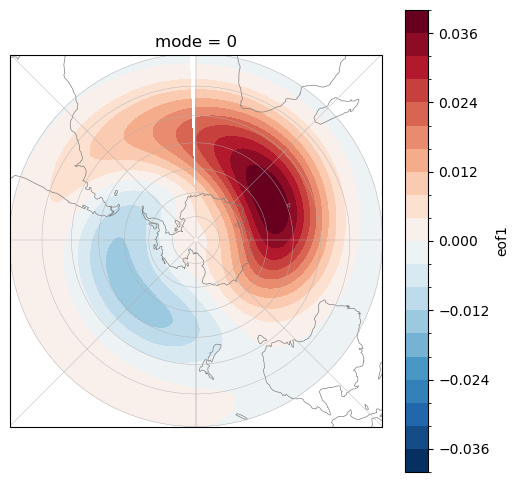

In [91]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = eof1.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [45]:
projected = pwt_anom_mon*eof1

In [59]:
pwt_anom[0]

<xarray.DataArray (lat: 36, lon: 180)> Size: 52kB
array([[-273207.74125596, -273213.52566515, -273219.08073606, ...,
        -273186.95181626, -273190.53383566, -273199.49243946],
       [-273619.7968007 , -273625.54151706, -273636.34675303, ...,
        -273603.11375853, -273607.4443189 , -273614.53930762],
       [-274067.80151727, -274074.17532197, -274084.28482743, ...,
        -274051.36428017, -274058.26959777, -274063.80902482],
       ...,
       [-304595.5529725 , -304595.80283805, -304596.16377568, ...,
        -304595.20446738, -304595.18597914, -304595.30362281],
       [-307144.11488205, -307143.9875639 , -307143.86535395, ...,
        -307144.86162012, -307144.55154529, -307144.33084201],
       [-313189.68724869, -313189.68724869, -313189.68724869, ...,
        -313189.68724869, -313189.68724869, -313189.68724869]])
Coordinates:
  * lon        (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev       float64 8B 1e+03
    time       datetime64[ns] 8B 1979-01-01
    dayofyear  int64 8B 1

In [57]:
pwt_anom_mon[0]

<xarray.DataArray (lat: 36, lon: 180)> Size: 52kB
array([[-274636.18096397, -274626.00476208, -274618.30244507, ...,
        -274668.75790207, -274658.11141657, -274646.85083788],
       [-274822.66293038, -274811.8032344 , -274803.46890802, ...,
        -274852.96890802, -274843.84666437, -274833.26136726],
       [-274984.1434614 , -274973.7045032 , -274963.55138416, ...,
        -275005.72250755, -275000.29019535, -274993.27111491],
       ...,
       [-263923.86114168, -263917.72546528, -263912.38217078, ...,
        -263946.9505947 , -263938.47396431, -263930.76465601],
       [-266119.59701721, -266116.66806008, -266113.94800143, ...,
        -266130.82417865, -266126.72195149, -266123.02123102],
       [-271548.87478261, -271548.87478261, -271548.87478261, ...,
        -271548.87478261, -271548.87478261, -271548.87478261]])
Coordinates:
  * lon        (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev       float64 8B 1e+03
    time       datetime64[ns] 8B 1979-06-01
    dayofyear  int64 8B 152

In [56]:
pwt_anom_mon[100]

<xarray.DataArray (lat: 36, lon: 180)> Size: 52kB
array([[-274565.58766462, -274554.92715431, -274544.11035281, ...,
        -274585.62871071, -274579.07790012, -274573.07126322],
       [-274772.17816761, -274762.56998926, -274751.80363038, ...,
        -274782.98791126, -274781.31419766, -274778.51723073],
       [-274947.7022106 , -274942.70161196, -274936.86364841, ...,
        -274944.47860655, -274946.9051323 , -274949.3599188 ],
       ...,
       [-261834.48409033, -261826.55394666, -261819.21084697, ...,
        -261861.63103308, -261852.05414146, -261842.96332193],
       [-263980.25980946, -263975.98087762, -263971.94683757, ...,
        -263994.87663146, -263989.64281472, -263984.84686286],
       [-269358.31228507, -269358.31228507, -269358.31228507, ...,
        -269358.31228507, -269358.31228507, -269358.31228507]])
Coordinates:
  * lon        (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev       float64 8B 1e+03
    time       datetime64[ns] 8B 1982-06-11
    dayofyear  int64 8B 162

In [53]:
projected[0]

<xarray.DataArray (lat: 36, lon: 180)> Size: 52kB
array([[ 4.17589123e+02,  4.24943914e+02,  4.34575264e+02, ...,
         3.84596585e+02,  3.97876607e+02,  4.09029938e+02],
       [ 1.87205041e+02,  1.95340404e+02,  2.04579960e+02, ...,
         1.47809053e+02,  1.63068720e+02,  1.76351720e+02],
       [-1.49814551e+02, -1.41044386e+02, -1.31766466e+02, ...,
        -1.89142661e+02, -1.74851494e+02, -1.61717603e+02],
       ...,
       [-7.05001428e+02, -7.13743856e+02, -7.22449886e+02, ...,
        -6.78614006e+02, -6.87427859e+02, -6.96223872e+02],
       [-4.98868342e+02, -5.01924580e+02, -5.04973308e+02, ...,
        -4.89583042e+02, -4.92687095e+02, -4.95774761e+02],
       [-1.80439700e-05, -1.80440134e-05, -1.80440115e-05, ...,
        -1.80439644e-05, -1.80439644e-05, -1.80439644e-05]])
Coordinates:
  * lon        (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    time       datetime64[ns] 8B 1979-06-01
    plev       float64 8B 1e+03
    dayofyear  int64 8B 152
    mode       int64 8B 0

In [52]:
projected[100]

<xarray.DataArray (lat: 36, lon: 180)> Size: 52kB
array([[ 4.17481785e+02,  4.24833932e+02,  4.34457857e+02, ...,
         3.84480186e+02,  3.97762117e+02,  4.08920058e+02],
       [ 1.87170651e+02,  1.95305409e+02,  2.04541497e+02, ...,
         1.47771419e+02,  1.63031618e+02,  1.76316593e+02],
       [-1.49794697e+02, -1.41028484e+02, -1.31753677e+02, ...,
        -1.89100538e+02, -1.74817551e+02, -1.61691780e+02],
       ...,
       [-6.99420221e+02, -7.08088454e+02, -7.16719911e+02, ...,
        -6.73252599e+02, -6.81993777e+02, -6.90716453e+02],
       [-4.94857936e+02, -4.97887014e+02, -5.00908683e+02, ...,
        -4.85653682e+02, -4.88730667e+02, -4.91791442e+02],
       [-1.78984108e-05, -1.78984538e-05, -1.78984519e-05, ...,
        -1.78984052e-05, -1.78984052e-05, -1.78984052e-05]])
Coordinates:
  * lon        (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    time       datetime64[ns] 8B 1982-06-11
    plev       float64 8B 1e+03
    dayofyear  int64 8B 162
    mode       int64 8B 0

In [47]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [66]:
np.sum(projected[1])

<xarray.DataArray ()> Size: 8B
array(-8489254.1555554)
Coordinates:
    time       datetime64[ns] 8B 1979-06-02
    plev       float64 8B 1e+03
    dayofyear  int64 8B 153
    mode       int64 8B 0

In [82]:
sum_proj = projected.sum("lat").sum("lon")

In [90]:
((sum_proj-sum_proj.mean("time"))/sum_proj.std("time"))[:30]

<xarray.DataArray (time: 30)> Size: 240B
array([-2.08323141, -1.79365852, -1.54153077, -1.30062899, -1.07548479,
       -0.86041738, -0.65927291, -0.540638  , -0.46050774, -0.46220497,
       -0.55872041, -0.63206799, -0.53716493, -0.3460057 , -0.18443783,
        0.00481178,  0.23026017,  0.33925159,  0.3685297 ,  0.40064376,
        0.49926012,  0.59720793,  0.58049737,  0.54529054,  0.65394171,
        0.94892071,  1.28796921,  1.64029451,  1.8830032 ,  2.06323213])
Coordinates:
  * time       (time) datetime64[ns] 240B 1979-06-01 1979-06-02 ... 1979-06-30
    plev       (time) float64 240B 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
    dayofyear  (time) int64 240B 152 153 154 155 156 157 ... 177 178 179 180 181
    mode       int64 8B 0

In [84]:
sum_proj.mean("time")

<xarray.DataArray ()> Size: 8B
array(-8442692.40198461)
Coordinates:
    mode     int64 8B 0

In [85]:
sum_proj.std("time")

<xarray.DataArray ()> Size: 8B
array(25959.09590771)
Coordinates:
    mode     int64 8B 0

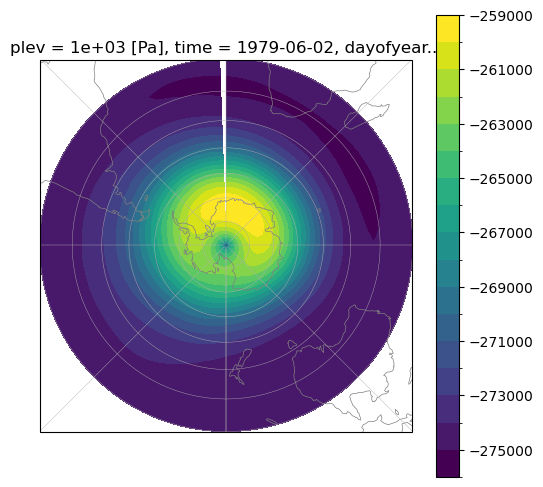

In [92]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = pwt_anom_mon[1].plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

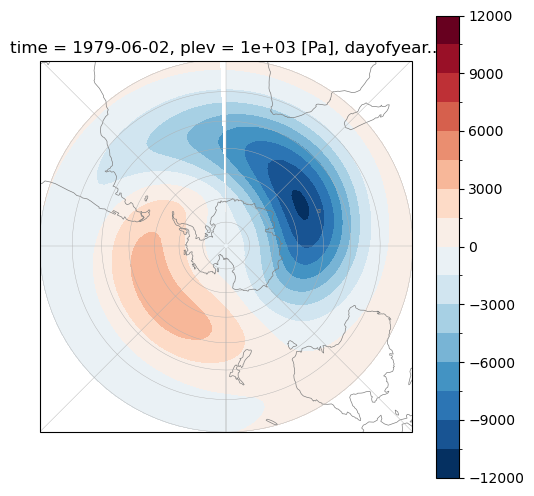

In [75]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = projected[1].plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

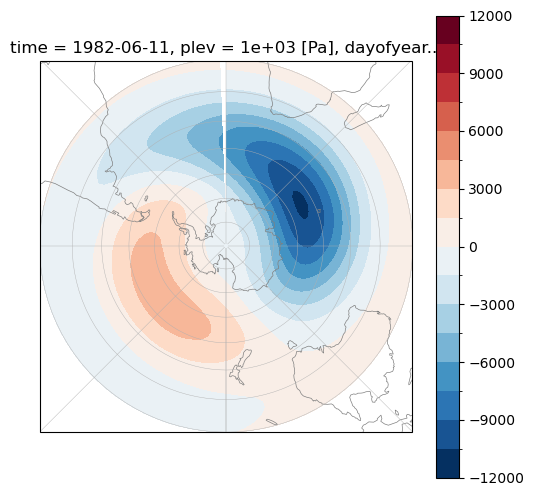

In [50]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = projected[100].plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [573]:
import numpy as np
import xarray as xr

def pc_month_like_ncl(z6h, eof_path, mon):
    """
    z6h: DataArray var129 (m^2/s^2) at 6-hourly cadence with dims (time, lat, lon)
    eof_path: file 'ERA5.EOF1.z<lv>.Mon<mon>.nc' containing 'eof1' on same grid/region
    mon: 1..12
    Returns: DataArray pc_std (year, day) standardized like NCL
    """
    # 1) daily mean in meters
    z_m = z6h.resample(time='1D', label='left', closed='left').mean() / 9.8

    # 2) select this month only
    z_mon = z_m.where(z_m.time.dt.month == mon, drop=True)

    # 3) climatology across years for each day-of-month (UNWEIGHTED)
    clim = z_mon.groupby('time.day').mean('time')
    anom = z_mon.groupby('time.day') - clim

    # 4) weighted anomalies pwt = anom * sqrt(cosφ)
    w = np.sqrt(np.cos(np.deg2rad(anom.lat)))
    pwt = anom * w

    # 5) load EOF and align grid/region; mask to EOF finite points
    eof = xr.open_dataset(eof_path)['eof1']
    eof = eof.sel(lat=pwt.lat, lon=pwt.lon)
    mask = np.isfinite(eof)
    pwt = pwt.where(mask)
    eof = eof.where(mask)

    # 6) projection: PLAIN sum in weighted space (no extra weights)
    pc = (pwt * eof).sum(['lat', 'lon']).sortby('time')   # daily series over years

    # 7) reshape to (year, day-of-month)
    pc_yd = (pc.assign_coords(year=pc.time.dt.year, day=pc.time.dt.day)
               .set_index(time=['year','day']).unstack('time')
               .transpose('year','day'))

    # 8) standardize across YEARS for each day-of-month (column-wise, ddof=1)
    mu  = pc_yd.mean('year')
    sd  = pc_yd.std('year', ddof=1)
    pc_std = (pc_yd - mu) / sd
    return pc_std

# Example usage
# pc_june = pc_month_like_ncl(gh_6h_mon['var129'], 'processed/zeof/ERA5.EOF1.z10.Mon06.nc', 6)
# compare row for 1979 to NCL


In [575]:
pc_june = pc_month_like_ncl(gh_6h_mon['var129'], 'processed/zeof/ERA5.EOF1.z10.Mon06.nc', 6)

/usr/local/Miniconda3-envs/envs/2024/envs/iacpy3_2024/lib/python3.11/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 45 times more chunks
  return self.array[key]


In [578]:
pc_june[1].values

array([ 1.83702388,  1.98975761,  2.2371002 ,  2.36658955,  2.39241575,
        2.16100292,  1.49112289,  0.66016189, -0.10349645, -0.71874345,
       -1.16248543, -1.35592754, -1.26107955, -1.06383144, -0.99831682,
       -1.03253001, -0.92377131, -0.59361245, -0.16082895,  0.24948798,
        0.66456515,  0.99709671,  1.19877847,  1.26819798,  1.27285495,
        1.15566937,  0.94105319,  0.64953027,  0.36408743,  0.31618912])